In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
    confusion_matrix, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'temperature': np.random.normal(80, 15, n),
    'vibration':   np.random.normal(0.5, 0.2, n),
    'pressure':    np.random.normal(30, 5, n),
    'rpm':         np.random.normal(3000, 200, n),
    'hours_run':   np.random.uniform(0, 5000, n)
})

# Failure rule: high temp OR high vibration OR near end-of-life
df['failure'] = (
    (df['temperature'] > 100) |
    (df['vibration']   > 0.85) |
    (df['hours_run']   > 4500)
).astype(int)

print(df.head(10))
print(f"\nDataset shape: {df.shape}")
print(f"Failure rate:  {df['failure'].mean():.2%}")
print(f"Normal:  {(df['failure']==0).sum()}  |  Failure: {(df['failure']==1).sum()}")

   temperature  vibration   pressure          rpm    hours_run  failure
0    87.450712   0.779871  26.624109  2618.438488  2425.089938        0
1    77.926035   0.684927  29.277407  2827.922998   427.015151        0
2    89.715328   0.511926  26.037900  2917.278893  4862.306950        1
3   102.845448   0.370613  28.460192  3377.537531  2590.052157        1
4    76.487699   0.639645  20.531927  3111.310625  3070.931222        0
5    76.487946   0.578697  31.066469  2732.903686  1183.048914        0
6   103.688192   0.679039  30.006027  3097.207258  2417.490426        1
7    91.511521   0.627034  25.914557  2690.539202  2145.747460        0
8    72.957884   0.709911  33.296228  3216.538211   374.479210        0
9    88.138401   0.392953  34.687851  2905.775070   530.801768        0

Dataset shape: (1000, 6)
Failure rate:  23.30%
Normal:  767  |  Failure: 233


In [3]:
print("--- Null values ---")
print(df.isnull().sum())

print("\n--- Basic statistics ---")
print(df.describe().round(2))


--- Null values ---
temperature    0
vibration      0
pressure       0
rpm            0
hours_run      0
failure        0
dtype: int64

--- Basic statistics ---
       temperature  vibration  pressure      rpm  hours_run  failure
count      1000.00    1000.00   1000.00  1000.00    1000.00  1000.00
mean         80.29       0.51     30.03  2996.26    2495.76     0.23
std          14.69       0.20      4.92   205.43    1450.80     0.42
min          31.38      -0.09     14.90  2414.11      30.92     0.00
25%          70.29       0.38     26.76  2852.52    1228.64     0.00
50%          80.38       0.51     30.00  3000.04    2457.37     0.00
75%          89.72       0.65     33.30  3133.39    3769.07     0.00
max         137.79       1.14     49.63  3648.62    4996.75     1.00


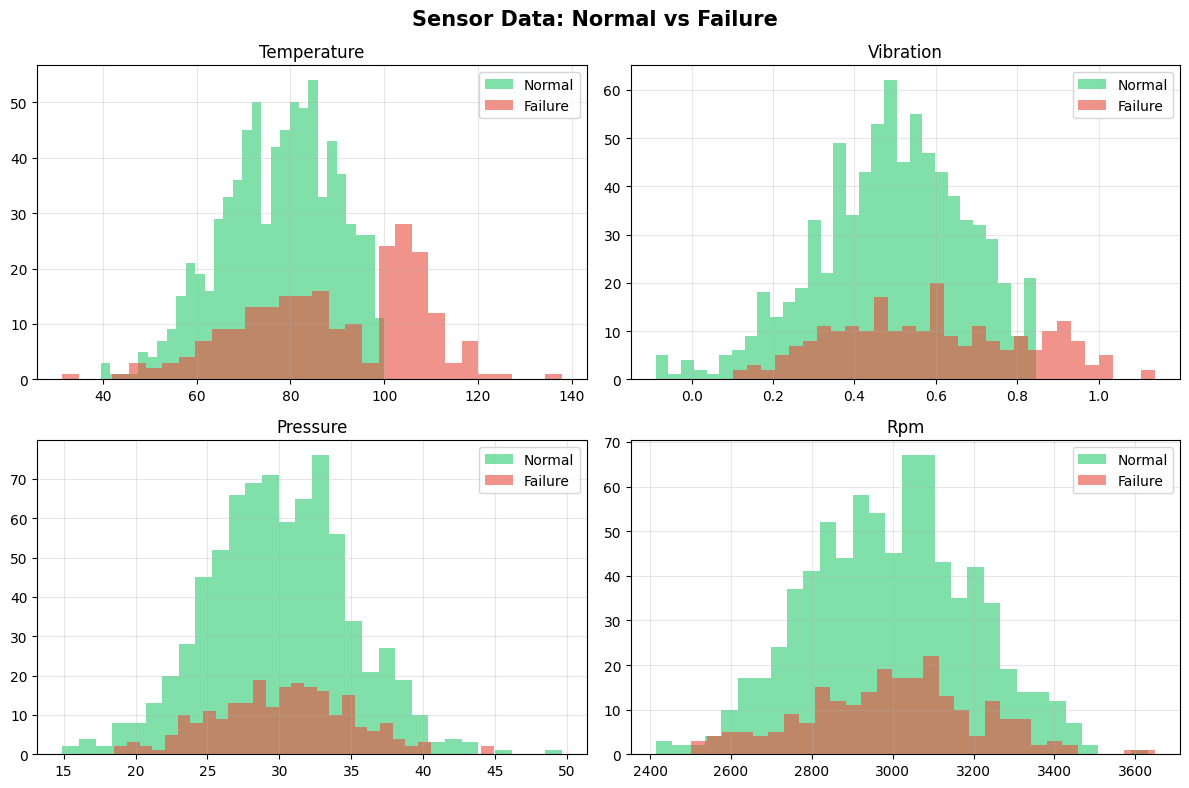

✅ Saved: sensor_distribution.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Sensor Data: Normal vs Failure', fontsize=15, fontweight='bold')

features = ['temperature', 'vibration', 'pressure', 'rpm']
colors   = {0: '#2ecc71', 1: '#e74c3c'}
labels   = {0: 'Normal',   1: 'Failure'}

for ax, feat in zip(axes.flatten(), features):
    for val in [0, 1]:
        subset = df[df['failure'] == val][feat]
        ax.hist(subset, bins=30, alpha=0.6,
                color=colors[val], label=labels[val])
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensor_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: sensor_distribution.png")

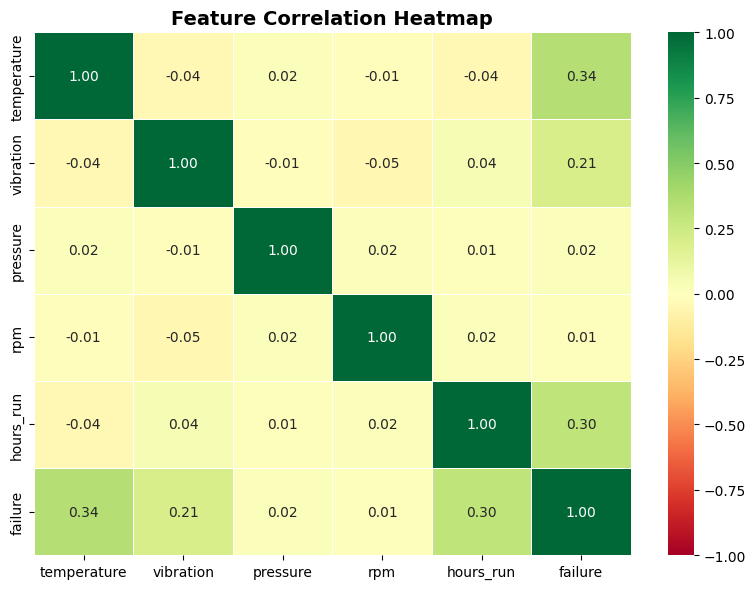

✅ Saved: correlation_heatmap.png


In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr().round(2),
            annot=True, cmap='RdYlGn',
            fmt='.2f', linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap.png")

In [6]:
X = df.drop('failure', axis=1)
y = df['failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"Features used:    {list(X.columns)}")

Training samples: 800
Test samples:     200
Features used:    ['temperature', 'vibration', 'pressure', 'rpm', 'hours_run']


In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {acc:.2%}\n")
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Normal', 'Failure']
))

✅ Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       153
     Failure       1.00      1.00      1.00        47

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



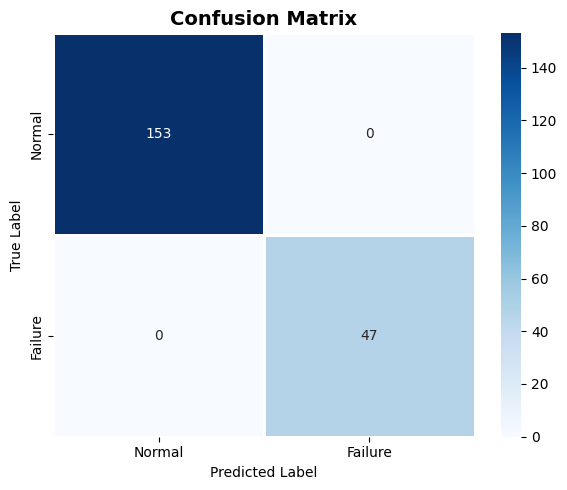

✅ Saved: confusion_matrix.png


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'],
            linewidths=1)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix.png")

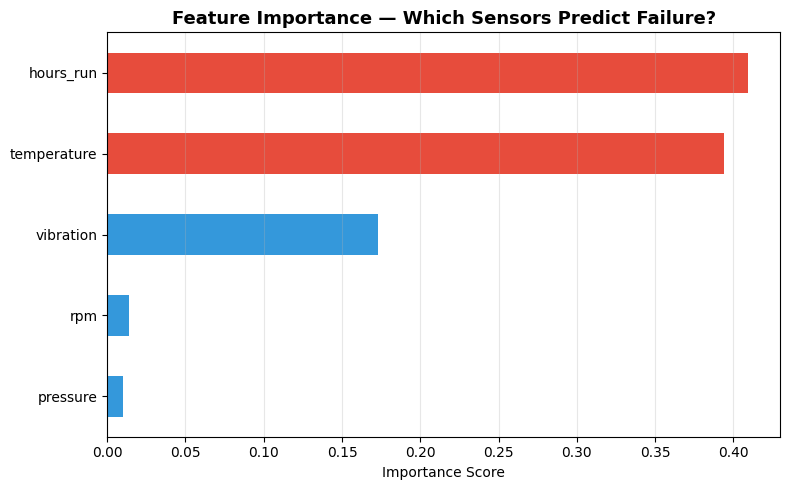

✅ Saved: feature_importance.png


In [9]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v > 0.2 else '#3498db'
          for v in importances.values]
importances.plot(kind='barh', color=colors)

plt.title('Feature Importance — Which Sensors Predict Failure?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

In [10]:
def predict_machine(temp, vib, pressure, rpm, hours, label=""):
    data = pd.DataFrame([[temp, vib, pressure, rpm, hours]],
                        columns=X.columns)
    pred  = model.predict(data)[0]
    prob  = model.predict_proba(data)[0][1]
    status = "🔴 FAILURE PREDICTED" if pred == 1 else "🟢 MACHINE NORMAL"
    bar = "█" * int(prob * 20) + "░" * (20 - int(prob * 20))
    print(f"{'─'*45}")
    print(f"  Machine: {label}")
    print(f"  Status:  {status}")
    print(f"  Risk:    [{bar}] {prob:.1%}")

# Test 1: healthy machine
predict_machine(72, 0.3, 28, 2900, 800,   label="Machine A — Healthy")

# Test 2: overheating
predict_machine(115, 0.4, 30, 3000, 1000, label="Machine B — High Temp")

# Test 3: high vibration
predict_machine(78, 0.95, 31, 3100, 2000, label="Machine C — High Vibration")

# Test 4: near end-of-life
predict_machine(82, 0.5, 29, 2950, 4800,  label="Machine D — Old Machine")
print(f"{'─'*45}")

─────────────────────────────────────────────
  Machine: Machine A — Healthy
  Status:  🟢 MACHINE NORMAL
  Risk:    [░░░░░░░░░░░░░░░░░░░░] 0.4%
─────────────────────────────────────────────
  Machine: Machine B — High Temp
  Status:  🔴 FAILURE PREDICTED
  Risk:    [███████████████████░] 98.2%
─────────────────────────────────────────────
  Machine: Machine C — High Vibration
  Status:  🔴 FAILURE PREDICTED
  Risk:    [███████████████████░] 99.0%
─────────────────────────────────────────────
  Machine: Machine D — Old Machine
  Status:  🔴 FAILURE PREDICTED
  Risk:    [███████████████████░] 98.2%
─────────────────────────────────────────────


In [11]:
acc = accuracy_score(y_test, y_pred)
total_failures = df['failure'].sum()
files = ['sensor_distribution.png', 'correlation_heatmap.png',
         'confusion_matrix.png',    'feature_importance.png']

print("="*50)
print("  AI-POWERED PREDICTIVE MAINTENANCE")
print("  PROJECT SUMMARY")
print("="*50)
print(f"  Dataset     : {len(df)} simulated IoT readings")
print(f"  Features    : {list(X.columns)}")
print(f"  Model       : Random Forest (100 trees)")
print(f"  Accuracy    : {acc:.2%}")
print(f"  Failures detected: {total_failures} / {len(df)}")
print("  Saved plots : " + ", ".join(files))
print("="*50)
print("  ✅ PROJECT COMPLETE — READY FOR GITHUB")
print("="*50)

  AI-POWERED PREDICTIVE MAINTENANCE
  PROJECT SUMMARY
  Dataset     : 1000 simulated IoT readings
  Features    : ['temperature', 'vibration', 'pressure', 'rpm', 'hours_run']
  Model       : Random Forest (100 trees)
  Accuracy    : 100.00%
  Failures detected: 233 / 1000
  Saved plots : sensor_distribution.png, correlation_heatmap.png, confusion_matrix.png, feature_importance.png
  ✅ PROJECT COMPLETE — READY FOR GITHUB
